In [2]:
import sys
import numpy as np
import anndata as ad
import polars as pl
import src as scit

/home/aleksander-work/Skrivbord/pyproject/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
mt_lsc = ad.read_h5ad('private/data/clean_method/mutant_landscape.h5ad')

In [4]:
for l in ('acet', 'meth'):
    bmask = mt_lsc.obsm[f'{l}'].copy()
    bmask.data = bmask.data > 0
    mt_lsc.obsm[f'{l}_masked_imp'] = mt_lsc.obsm[f'{l}_imp'].multiply(bmask)

In [5]:
active_meth = pl.read_csv('private/data/meth_active.csv', has_header=False)['column_1'].to_numpy()

In [6]:
lc_acet = scit.tl.make_layer_config(
    "acet",
    in_obsm=True,
    normalize_with_obs_counts=True,
    feature_names=mt_lsc.uns['gene_names_acet']
)
lc_meth = scit.tl.make_layer_config(
    "meth",
    in_obsm=True,
    normalize_with_obs_counts=True,
    feature_names=mt_lsc.uns['gene_names_acet']
)

Info: Added Griddata to .uns[cat_label]


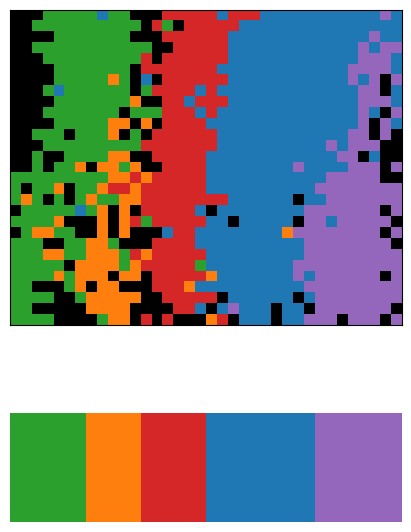

In [10]:
scit.adv.griddata_categorical(mt_lsc, 'label', 4)
scit.adv.pl.categorical2d(mt_lsc, 'cat_label')

In [11]:
scit.tl.layer_pick_features(mt_lsc, lc_meth, active_meth)
scit.tl.layer_pick_features(mt_lsc, lc_acet, active_meth)
scit.adv.griddata_numerical(mt_lsc, lc_meth, min_cells=5, use_cached_mask=True)
scit.adv.griddata_numerical(mt_lsc, lc_acet, min_cells=5, use_cached_mask=True)

Info: Added Griddata to .uns[meth]
Info: Added Griddata to .uns[acet]


In [9]:
scit.adv.griddata_apply_transformations(mt_lsc, lc_meth.layer, (0.5,0.5), n_median_passes=1)
scit.adv.griddata_apply_transformations(mt_lsc, lc_acet.layer, (0.5,0.5), n_median_passes=1)

Info: Added Griddata to .uns[t_meth_masked_imp]
Info: Added Griddata to .uns[t_acet_masked_imp]


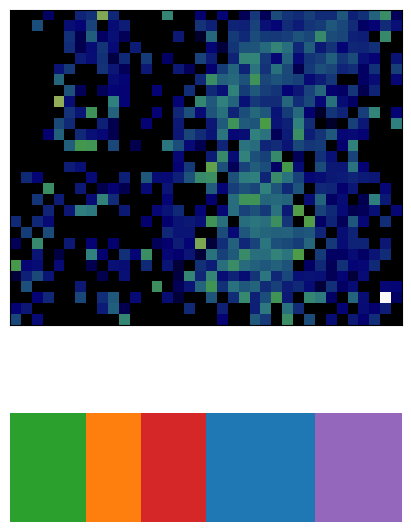

In [12]:
scit.set_defaults(figsize=(4,6))

scit.adv.pl.landscape2d(mt_lsc, lc_meth.layer, 'dysf')
#scit.adv.pl.landscape2d(mt_lsc, f't_{lc_meth.layer}', 'Ctr1B')

In [10]:
dyn_meth = scit.adv.landscape_dynamics(
    mt_lsc,
    lc_meth.layer,
    'cat_label',
    spearman=True
)
dyn_acet = scit.adv.landscape_dynamics(
    mt_lsc,
    lc_acet.layer,
    'cat_label',
    spearman=True
)

shape: (5, 3)
┌───────┬───────────┬──────────┐
│ group ┆ res       ┆ var_name │
│ ---   ┆ ---       ┆ ---      │
│ i32   ┆ f32       ┆ str      │
╞═══════╪═══════════╪══════════╡
│ 0     ┆ -0.052843 ┆ rau      │
│ 1     ┆ -0.022685 ┆ rau      │
│ 2     ┆ -0.030977 ┆ rau      │
│ 3     ┆ -0.077678 ┆ rau      │
│ 4     ┆ 0.136197  ┆ rau      │
└───────┴───────────┴──────────┘


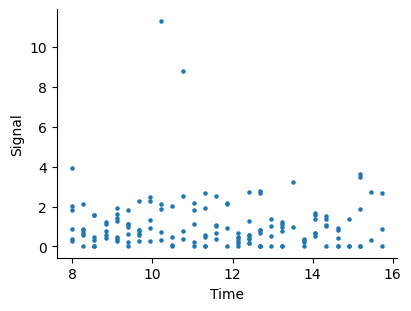

In [17]:
scit.set_defaults(figsize=(4,3))
gn = 'rau'
print(dyn_acet.filter(pl.col('var_name') == gn)) #GATAe=0.36
scit.adv.pl.time_correlation(
    mt_lsc, lc_acet.layer, 'cat_label', 'label', 'Muscle', gn)

In [19]:
scit.tl.summarize_data(
    cttag,
    get_current_layer_active(),
    obs_key='label_own',
    binary=True
)
scit.adv.dynamics_add_expression_data(
    cttag,
    dyn,
    cttag.uns['gene_names_acet'],
    cttag.uns[f'sum_active_class_{current_modality}_binary_active_adj_contrast_label_own'],
)

NameError: name 'get_current_layer_active' is not defined

In [11]:
dyn_meth.filter(pl.col('group') == 3, pl.col('res') > 0.2)

group,res,var_name
i32,f32,str
3,0.201964,"""CG6753"""
3,0.21355,"""CG42788"""
3,0.222015,"""CG11768"""
3,0.228466,"""CG5023"""
3,0.224344,"""CG6254"""
…,…,…
3,NaN,"""18SrRNA:CR45841"""
3,NaN,"""SteXh:CG42398"""
3,NaN,"""Su(Ste):CR42418"""


In [12]:
dyn_meth.write_csv('private/newest/muscle_dynamics_meth.csv')
dyn_acet.write_csv('private/newest/muscle_dynamics_acet.csv')

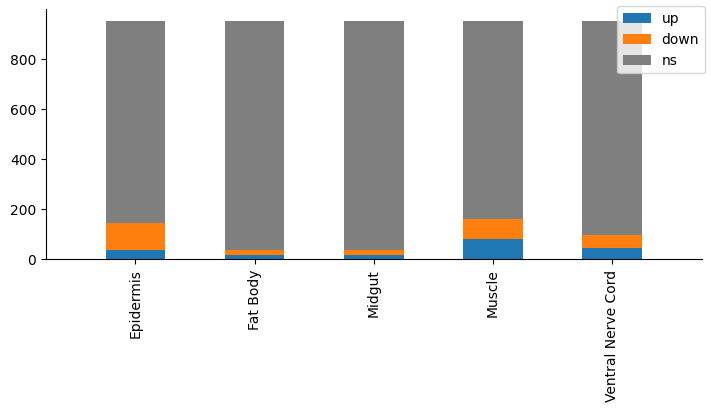

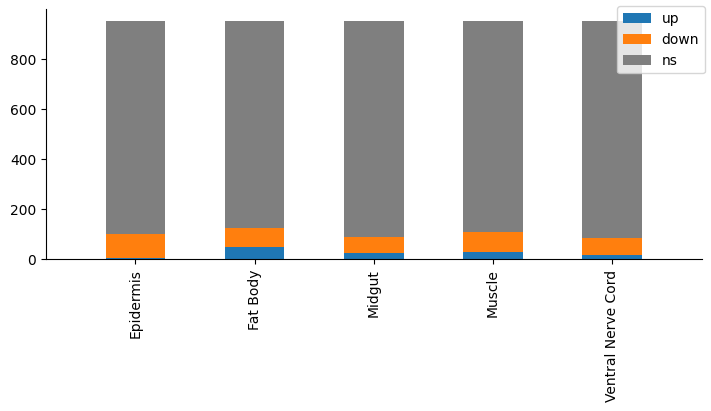

In [16]:
scit.set_defaults(figsize=(7,4))
scit.adv.pl.differential_dynamics(
    mt_lsc,
    dyn_meth,
    'label',
    activity_threshold=3,
    abs_correlation_threshold=0.3,
    active_only=False
)
scit.adv.pl.differential_dynamics(
    mt_lsc,
    dyn_acet,
    'label',
    activity_threshold=3,
    abs_correlation_threshold=0.2,
    active_only=False
)

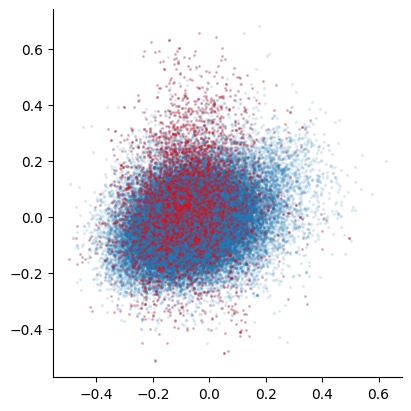

In [38]:
df = dyn_acet.join(dyn_meth, on=('var_name', 'group'), suffix='_meth')

scit.set_defaults(figsize=(4,4))
f = scit.pl.int.scatter(np.c_[
    df['res'].to_numpy(),
    df['res_meth'].to_numpy()
], alpha=0.1, s=2, show=False)

df = df.filter(pl.col('var_name').is_in(cttag.uns['gene_names_acet'][active_meth]))

f.axes[0].scatter(df['res'].to_numpy(), df['res_meth'].to_numpy(), s=1, alpha=0.2, c='r')